# Running DD-experiments
- {7, 8, 9, 10}-qubit GHZ circuit with 4096 shots x3 (for averaging).
- Batch mode suitable with PUB as [(isa_ghz), (isa_ghz_dd)] 
- Normal Transpilation (isa_ghz) :- Transpiling for backend with optimization_level = 3
- DD Transpilation (isa_ghz_dd) :- Using a Pass manager for Padding DD with ALAP scheduelling 

In [1]:
from qiskit.circuit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager, PassManager
from qiskit.transpiler.passes.scheduling import ALAPScheduleAnalysis, ASAPScheduleAnalysis, PadDynamicalDecoupling
from qiskit_ibm_runtime.fake_provider import FakeBrisbane 
from qiskit_ibm_runtime.estimator import EstimatorOptions, EstimatorV2 as Estimator
from qiskit_ibm_runtime import Batch, QiskitRuntimeService
from qiskit.providers.backend import BackendV2 as Backend
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import XGate 
from qiskit.quantum_info import hellinger_fidelity, SparsePauliOp
import numpy as np
import pandas as pd 
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_aer.primitives import EstimatorV2 as AerEstimator

In [14]:
def prepare_ghz(n_qubits: int):
    ## Prepares standard ghz state with measurements on all qubits using measure_all() 
    circuit = QuantumCircuit(n_qubits)
    circuit.h(0)
    for i in range(0, n_qubits-1):
        circuit.cx(i, i+1)

    circuit.measure_all()

    return circuit

def prepare_echo_ghz_with_xs(n_qubits:int):
    ## Prepares echo circuit with for ghz circuit. Xs at the end to make the expectation value 1. 
    circuit = QuantumCircuit(n_qubits)
    circuit.h(0)
    for i in range(0, n_qubits-1):
        circuit.cx(i, i+1)

    circuit.barrier()

    circuit.compose(circuit.inverse(), inplace=True)

    circuit.barrier()

    circuit.x(range(n_qubits))

    circuit.measure_all()

    return circuit


def naked_estimator(mode):
    ## Estimator with no error mitigation or supression for any mode (job, batch). ALL OPTIONS ARE DISABLED. 
    estimator_options = EstimatorOptions(default_shots=4096, seed_estimator=42069, dynamical_decoupling={"enable": False},twirling={"enable_gates": False, "enable_measure": False},resilience_level=0, resilience={"measure_mitigation":False, "zne_mitigation":False, "pec_mitigation":False}) 

    estimator = Estimator(mode=mode, options=estimator_options)
    return estimator

def noiseless_estimator_pub(actual_qubits:int, isa_circuit:QuantumCircuit, pauli="Z"):

    ## Creating Pauli Op and mapping the operator to correct qubits. Note: this can be avoided as our observable is "ZZ..Z" but still going with the procedure
    isa_observable = SparsePauliOp(pauli*actual_qubits).apply_layout(isa_circuit.layout)

    pub = (isa_circuit, isa_observable)

    return pub


def estimator_pub(isa_circuit:QuantumCircuit, isa_dd_xx_circuit:QuantumCircuit, isa_dd_xpxm_circuit:QuantumCircuit, pauli="Z"):
    ## NOTE: isa_circuit and isa_dd_circuit must have the same no. of "actual qubit"
    ## Creating Pauli Op and mapping the operator to correct qubits. 
    actual_qubits = len(isa_circuit.layout.final_index_layout())
    isa_observable    = SparsePauliOp(pauli*actual_qubits).apply_layout(isa_circuit.layout)
    isa_dd_xx_observable = SparsePauliOp(pauli*actual_qubits).apply_layout(isa_dd_xx_circuit.layout)
    isa_dd_xpxm_observable = SparsePauliOp(pauli*actual_qubits).apply_layout(isa_dd_xpxm_circuit.layout)
    

    pub = [(isa_circuit, isa_observable), (isa_dd_xx_circuit, isa_dd_xx_observable), (isa_dd_xpxm_circuit, isa_dd_xpxm_observable)]

    return pub





def pm_for_backend(bknd: Backend, opt_level, seed=42069):
    ## Returns a PassManager from generate_preset_pass_manager for given opt_level and backend(bknd)
    pm = generate_preset_pass_manager(optimization_level=opt_level, backend=bknd, seed_transpiler=seed)
    return pm


def prepare_dd_pm(backend: Backend, scheduling_method="alap", seq="XX"):
    ## Returns a PassManager for DD with customizable DD sequence and scheduelling method. 
    
    # Default Sequence
    sequenece = [XGate(), XGate()]

    if seq.lower() == "xpxm":
        sequenece = [XGate(), XGate().inverse()]

    target = backend.target
    ## Prepare a preset passmanager for backend optimization_level=3
    pm = pm_for_backend(bknd=backend, opt_level=3, seed=42069)

    if scheduling_method == "alap":
        pm.scheduling.append(ALAPScheduleAnalysis(target=target))
        pm.scheduling.append(PadDynamicalDecoupling(target=target, dd_sequence=sequenece))

    elif scheduling_method == "asap":
        pm.scheduling.append(ASAPScheduleAnalysis(target=target))
        pm.scheduling.append(PadDynamicalDecoupling(target=target, dd_sequence=sequenece))
        
    return pm


def transpile_for_dd(circuit, dd_pm, backend):
    
    isa_dd_circuit = dd_pm.run(circuit)
    
    return isa_dd_circuit


def execute_on_hardware(bknd :Backend , estimator_pub):
    ## Batch mode execution of quantum circuits on hardware
    
    with Batch(backend=bknd) as batch:
        estimator = naked_estimator(mode=batch)
        job = estimator.run(estimator_pub)
        id = job.job_id()
        print(id)
    return id


def get_result_from_id(service: QiskitRuntimeService, id: str):
    # Get Result object from service using id

    job = service.job(id)
    result = job.result()

    return result
    

def summarize_backend(backend):
    """Return a structured snapshot of backend properties for an online IBMBackend."""
    try:
        config = backend.configuration()
    except Exception:
        config = None

    try:
        props = backend.properties()
    except Exception:
        props = None

    num_qubits = getattr(backend, "num_qubits", None)
    if callable(num_qubits):
        num_qubits = num_qubits()

    dt = None
    if config and hasattr(config, "dt"):
        dt = getattr(config, "dt", None)
    elif getattr(backend, "dt", None):
        dt = backend.dt
    elif getattr(getattr(backend, "target", None), "dt", None):
        dt = backend.target.dt

    granularity = None
    if config and getattr(config, "timing_constraints", None):
        granularity = config.timing_constraints.get("granularity")
    if granularity is None and getattr(getattr(backend, "target", None), "granularity", None):
        granularity = backend.target.granularity

    summary = {
        "backend_name": getattr(backend, "name", lambda: str(backend)),
        "num_qubits": num_qubits or (getattr(config, "num_qubits", None) if config else None),
        "basis_gates": [],
        "supported_instructions": [],
        "coupling_map": None,
        "qubit_properties": [],
        "gate_parameters": [],
        "last_update": None,
        "dt": dt,
        "granularity": granularity,
    }

    target = getattr(backend, "target", None)
    if config and getattr(config, "basis_gates", None):
        summary["basis_gates"] = list(config.basis_gates)
    elif target is not None:
        summary["basis_gates"] = list(target.operations)

    if target is not None:
        summary["supported_instructions"] = list(target.operations)

    coupling_map = None
    if config and getattr(config, "coupling_map", None):
        coupling_map = [list(edge) for edge in config.coupling_map]
    elif getattr(backend, "coupling_map", None):
        cm = backend.coupling_map
        if cm:
            coupling_map = [list(edge) for edge in cm]
    elif target is not None:
        try:
            target_map = target.build_coupling_map()
            if target_map:
                coupling_map = [list(edge) for edge in target_map.get_edges()]
        except Exception:
            pass
    summary["coupling_map"] = coupling_map

    if props:
        props_dict = props.to_dict()
        for qubit_index, qubit_props in enumerate(props_dict.get("qubits", [])):
            values = {entry["name"]: entry["value"] for entry in qubit_props}
            readout_error = values.get("readout_error")
            if readout_error is None and {"prob_meas0_prep1", "prob_meas1_prep0"}.issubset(values):
                readout_error = (values["prob_meas0_prep1"] + values["prob_meas1_prep0"]) / 2

            summary["qubit_properties"].append({
                "qubit": qubit_index,
                "t1": values.get("T1"),
                "t2": values.get("T2"),
                "frequency": values.get("frequency"),
                "readout_error": readout_error,
            })

        for gate in props_dict.get("gates", []):
            params = {param["name"]: param["value"] for param in gate.get("parameters", [])}
            summary["gate_parameters"].append({
                "gate": gate.get("gate"),
                "qubits": gate.get("qubits"),
                "gate_error": params.get("gate_error"),
                "gate_length": params.get("gate_length"),
            })

        summary["last_update"] = props_dict.get("last_update_date")

    return summary

## Circuit generation and transpilation

In [15]:
## Prepare circuit dict
circuit_dict = {f"{i}":prepare_echo_ghz_with_xs(n_qubits=i) for i in range(7, 11)}
circuit_dict

{'7': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7fb29dd48150>,
 '8': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7fb29dd49f50>,
 '9': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7fb2e0351cd0>,
 '10': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7fb29d7ac950>}

In [16]:
## Transpile circuit for torino backend
service = QiskitRuntimeService(name="qamp-2025")

marrakesh = service.backend("ibm_marrakesh")

## Transpiler with optimization_level=3
pm3 = pm_for_backend(marrakesh, 3, 42069) # args: backend, optimization_level, seed_transpiler
isa_dict = {f"{i}":pm3.run(circuit_dict[f"{i}"]) for i in range(7, 11)}

## Transpile for DD

dd_xpxm_pm = prepare_dd_pm(marrakesh, seq="XpXm", scheduling_method="alap")

dd_xx_pm = prepare_dd_pm(marrakesh, seq="XX", scheduling_method="alap")


isa_dd_xpxm_dict = {f"{i}":transpile_for_dd(circuit_dict[f"{i}"], dd_xpxm_pm, marrakesh) for i in range(7, 11)}

isa_dd_xx_dict = {f"{i}":transpile_for_dd(circuit_dict[f"{i}"], dd_xx_pm, marrakesh) for i in range(7, 11)}


print(isa_dict)



management.get:WARNING:2025-11-30 03:52:44,430: Loading saved account: qamp-2025


{'7': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7fb29dd13790>, '8': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7fb29daf3650>, '9': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7fb29da23d90>, '10': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7fb29d977250>}


In [17]:
isa_dict["7"].draw(fold=-1)

global phase: π/2
           ┌─────────┐┌────┐ ┌───────┐                                            ┌────┐┌─────────┐                                                             ░  ░                                                                                                  ┌─────────┐   ┌────┐  ┌───────┐      ┌────┐  ┌─────────┐                                                                                ░ ┌───┐ ░          ┌─┐         
 q_3 -> 91 ┤ Rz(π/2) ├┤ √X ├─┤ Rz(π) ├──────────────────────────────────────────■─┤ √X ├┤ Rz(π/2) ├─■───────────────────────────────────────────────────────────░──░────────────────────────────────────────────────────────────────────────────────────────────────■─┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├─■────┤ √X ├──┤ Rz(π/2) ├────────────────────────────────────────────────────────────────────────────────░─┤ X ├─░──────────┤M├─────────
           ├─────────┤├────┤ ├───────┤                                          │ └────┘└─────────┘ │ ┌────┐┌─────────┐                                         ░  ░                                                                ┌─────────┐   ┌────┐  ┌───────┐ │ └──┬────┬─┘┌──┴────┴─┐└───────┘ │    └────┘  └─────────┘                                                                                ░ ├───┤ ░          └╥┘┌─┐      
 q_4 -> 92 ┤ Rz(π/2) ├┤ √X ├─┤ Rz(π) ├──────────────────────────────────────────┼───────────────────■─┤ √X ├┤ Rz(π/2) ├─■───────────────────────────────────────░──░──────────────────────────────────────────────────────────────■─┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├─■────┤ √X ├──┤ Rz(π/2) ├──────────┼───────────────────────────────────────────────────────────────────────────────────────────────────────░─┤ X ├─░───────────╫─┤M├──────
           ├─────────┤├────┤ ├───────┤                                          │                     └────┘└─────────┘ │ ┌────┐┌─────────┐                     ░  ░                              ┌─────────┐   ┌────┐  ┌───────┐ │ └──┬────┬─┘┌──┴────┴─┐└───────┘      └────┘  └─────────┘          │                                                                                                       ░ ├───┤ ░           ║ └╥┘┌─┐   
 q_5 -> 93 ┤ Rz(π/2) ├┤ √X ├─┤ Rz(π) ├──────────────────────────────────────────┼───────────────────────────────────────■─┤ √X ├┤ Rz(π/2) ├─■───────────────────░──░────────────────────────────■─┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├─■────┤ √X ├──┤ Rz(π/2) ├────────────────────────────────────────────┼───────────────────────────────────────────────────────────────────────────────────────────────────────░─┤ X ├─░───────────╫──╫─┤M├───
           ├─────────┤├────┤ ├───────┤                                          │                                         └────┘└─────────┘ │ ┌────┐┌─────────┐ ░  ░ ┌─────────┐┌────┐┌───────┐ │ └──┬────┬─┘┌──┴────┴─┐└───────┘      └────┘  └─────────┘                                            │                                                                                                       ░ ├───┤ ░           ║  ║ └╥┘┌─┐
 q_6 -> 94 ┤ Rz(π/2) ├┤ √X ├─┤ Rz(π) ├──────────────────────────────────────────┼───────────────────────────────────────────────────────────■─┤ √X ├┤ Rz(π/2) ├─░──░─┤ Rz(π/2) ├┤ √X ├┤ Rz(π) ├─■────┤ √X ├──┤ Rz(π/2) ├──────────────────────────────────────────────────────────────────────────────┼───────────────────────────────────────────────────────────────────────────────────────────────────────░─┤ X ├─░───────────╫──╫──╫─┤M├
           ├─────────┤├────┤ ├───────┤                        ┌────┐┌─────────┐ │                                                             └────┘└─────────┘ ░  ░ └─────────┘└────┘└───────┘      └────┘  └─────────┘                                                                              │ ┌─────────┐   ┌────┐  ┌───────┐      ┌────┐  ┌─────────┐                                              ░ ├───┤ ░       ┌─┐ ║  ║  ║ └╥┘
 q_2 -> 98 ┤ Rz(π/2) ├┤ √X ├─┤ Rz(π) ├──────────────────────■─┤ √X ├┤ Rz(π/2) ├─■───────────────────────────────

In [18]:
isa_dd_xx_dict["7"].draw(fold=-1)

global phase: π/2
           ┌───────────────┐ ┌─────────┐   ┌────┐  ┌───────┐                                                                                                      ┌────┐        ┌─────────┐                    ┌───────────────┐      ┌───┐      ┌───────────────┐     ┌───┐      ┌───────────────┐                                                 ░  ░ ┌───────────────┐┌───┐ ┌───────────────┐┌───┐┌───────────────┐                                                                            ┌─────────┐   ┌────┐    ┌───────┐             ┌──────────────┐┌───┐ ┌───────────────┐┌───┐┌──────────────┐┌────┐  ┌─────────┐                                               ░ ┌───┐ ░          ┌─┐         
 q_3 -> 91 ┤ Delay(52[dt]) ├─┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├───────────────────────────────────────────────────────────────────────────────────────■──────────────┤ √X ├────────┤ Rz(π/2) ├───────────■────────┤ Delay(10[dt]) ├──────┤ X ├──────┤ Delay(23[dt]) ├─────┤ X ├──────┤ Delay(10[dt]) ├─────────────────────────────────────────────────░──░─┤ Delay(10[dt]) ├┤ X ├─┤ Delay(23[dt]) ├┤ X ├┤ Delay(10[dt]) ├──────────────────────────────────────────────────────────────────────■─────┤ Rz(π/2) ├───┤ √X ├────┤ Rz(π) ├──────────■──┤ Delay(8[dt]) ├┤ X ├─┤ Delay(18[dt]) ├┤ X ├┤ Delay(8[dt]) ├┤ √X ├──┤ Rz(π/2) ├───────────────────────────────────────────────░─┤ X ├─░──────────┤M├─────────
           ├───────────────┤ ├─────────┤   ├────┤  ├───────┤                                                                                       │              └────┘        └─────────┘           │        └─────┬────┬────┘   ┌──┴───┴──┐   └───────────────┘┌────┴───┴─────┐└─────┬───┬─────┘┌──────────────┐     ┌───┐      ┌──────────────┐ ░  ░ └┬──────────────┤├───┤ └┬──────────────┤├───┤└┬──────────────┤                               ┌─────────┐   ┌────┐    ┌───────┐      │  ┌──┴─────────┴──┐├───┬┘┌───┴───────┴───┐┌───┐ │ ┌┴──────────────┤├───┴┐└──┬─────────┬──┘└───┘└──────────────┘└────┘  └─────────┘                                               ░ ├───┤ ░          └╥┘┌─┐      
 q_4 -> 92 ┤ Delay(78[dt]) ├─┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├───────────────────────────────────────────────────────────────────────────────────────┼──────────────────────────────────────────────────■──────────────┤ √X ├────────┤ Rz(π/2) ├───────────■────────┤ Delay(4[dt]) ├──────┤ X ├──────┤ Delay(9[dt]) ├─────┤ X ├──────┤ Delay(4[dt]) ├─░──░──┤ Delay(4[dt]) ├┤ X ├──┤ Delay(9[dt]) ├┤ X ├─┤ Delay(4[dt]) ├─────────────────────────■─────┤ Rz(π/2) ├───┤ √X ├────┤ Rz(π) ├──────■──┤ Delay(15[dt]) ├┤ X ├─┤ Delay(30[dt]) ├┤ X ├─┼─┤ Delay(15[dt]) ├┤ √X ├───┤ Rz(π/2) ├──────────────────────────────────────────────────────────────────────────────────────────░─┤ X ├─░───────────╫─┤M├──────
           ├───────────────┴┐├─────────┤   ├────┤  ├───────┤                                                                                       │                                                                 └────┘        └─────────┘           │        └────┬────┬────┘   ┌──┴───┴──┐   └──────────────┘┌────┴───┴─────┐└──────────────┘ ░  ░  ├──────────────┤└───┘  └──────────────┘└───┘ └─┬─────────┬──┘┌────┐    ┌───────┐      │  ┌──┴─────────┴──┐├───┬┘┌───┴───────┴───┐┌───┐├───────────────┤├───┴┐└──┬─────────┬──┘└───┘ │ └───────────────┘└────┘   └─────────┘                                                                                          ░ ├───┤ ░           ║ └╥┘┌─┐   
 q_5 -> 93 ┤ Delay(104[dt]) ├┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├───────────────────────────────────────────────────────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────────────────────────────────■─────────────┤ √X ├────────┤ Rz(π/2) ├──────────■────────┤ Delay(9[dt]) ├─────────────────░──░──┤ Delay(9[dt]) ├─────────────────────────■─────┤ Rz(π/2) ├───┤ √X ├────┤ Rz(π) ├──────■──┤ Delay(21[dt]) ├┤ X ├─┤ Delay(44[dt]) ├┤ X ├┤ Delay(21[dt]) ├┤ √X ├───┤ Rz(π/2) ├─────────┼────────────────────

In [19]:
isa_dd_xpxm_dict["7"].draw(fold=-1)

global phase: π/2
           ┌───────────────┐ ┌─────────┐   ┌────┐  ┌───────┐                                                                                                      ┌────┐        ┌─────────┐                    ┌───────────────┐      ┌───┐      ┌───────────────┐     ┌───┐      ┌───────────────┐                                                 ░  ░ ┌───────────────┐┌───┐ ┌───────────────┐┌───┐┌───────────────┐                                                                            ┌─────────┐   ┌────┐    ┌───────┐             ┌──────────────┐┌───┐ ┌───────────────┐┌───┐┌──────────────┐┌────┐  ┌─────────┐                                               ░ ┌───┐ ░          ┌─┐         
 q_3 -> 91 ┤ Delay(52[dt]) ├─┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├───────────────────────────────────────────────────────────────────────────────────────■──────────────┤ √X ├────────┤ Rz(π/2) ├───────────■────────┤ Delay(10[dt]) ├──────┤ X ├──────┤ Delay(23[dt]) ├─────┤ X ├──────┤ Delay(10[dt]) ├─────────────────────────────────────────────────░──░─┤ Delay(10[dt]) ├┤ X ├─┤ Delay(23[dt]) ├┤ X ├┤ Delay(10[dt]) ├──────────────────────────────────────────────────────────────────────■─────┤ Rz(π/2) ├───┤ √X ├────┤ Rz(π) ├──────────■──┤ Delay(8[dt]) ├┤ X ├─┤ Delay(18[dt]) ├┤ X ├┤ Delay(8[dt]) ├┤ √X ├──┤ Rz(π/2) ├───────────────────────────────────────────────░─┤ X ├─░──────────┤M├─────────
           ├───────────────┤ ├─────────┤   ├────┤  ├───────┤                                                                                       │              └────┘        └─────────┘           │        └─────┬────┬────┘   ┌──┴───┴──┐   └───────────────┘┌────┴───┴─────┐└─────┬───┬─────┘┌──────────────┐     ┌───┐      ┌──────────────┐ ░  ░ └┬──────────────┤├───┤ └┬──────────────┤├───┤└┬──────────────┤                               ┌─────────┐   ┌────┐    ┌───────┐      │  ┌──┴─────────┴──┐├───┬┘┌───┴───────┴───┐┌───┐ │ ┌┴──────────────┤├───┴┐└──┬─────────┬──┘└───┘└──────────────┘└────┘  └─────────┘                                               ░ ├───┤ ░          └╥┘┌─┐      
 q_4 -> 92 ┤ Delay(78[dt]) ├─┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├───────────────────────────────────────────────────────────────────────────────────────┼──────────────────────────────────────────────────■──────────────┤ √X ├────────┤ Rz(π/2) ├───────────■────────┤ Delay(4[dt]) ├──────┤ X ├──────┤ Delay(9[dt]) ├─────┤ X ├──────┤ Delay(4[dt]) ├─░──░──┤ Delay(4[dt]) ├┤ X ├──┤ Delay(9[dt]) ├┤ X ├─┤ Delay(4[dt]) ├─────────────────────────■─────┤ Rz(π/2) ├───┤ √X ├────┤ Rz(π) ├──────■──┤ Delay(15[dt]) ├┤ X ├─┤ Delay(30[dt]) ├┤ X ├─┼─┤ Delay(15[dt]) ├┤ √X ├───┤ Rz(π/2) ├──────────────────────────────────────────────────────────────────────────────────────────░─┤ X ├─░───────────╫─┤M├──────
           ├───────────────┴┐├─────────┤   ├────┤  ├───────┤                                                                                       │                                                                 └────┘        └─────────┘           │        └────┬────┬────┘   ┌──┴───┴──┐   └──────────────┘┌────┴───┴─────┐└──────────────┘ ░  ░  ├──────────────┤└───┘  └──────────────┘└───┘ └─┬─────────┬──┘┌────┐    ┌───────┐      │  ┌──┴─────────┴──┐├───┬┘┌───┴───────┴───┐┌───┐├───────────────┤├───┴┐└──┬─────────┬──┘└───┘ │ └───────────────┘└────┘   └─────────┘                                                                                          ░ ├───┤ ░           ║ └╥┘┌─┐   
 q_5 -> 93 ┤ Delay(104[dt]) ├┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├───────────────────────────────────────────────────────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────────────────────────────────■─────────────┤ √X ├────────┤ Rz(π/2) ├──────────■────────┤ Delay(9[dt]) ├─────────────────░──░──┤ Delay(9[dt]) ├─────────────────────────■─────┤ Rz(π/2) ├───┤ √X ├────┤ Rz(π) ├──────■──┤ Delay(21[dt]) ├┤ X ├─┤ Delay(44[dt]) ├┤ X ├┤ Delay(21[dt]) ├┤ √X ├───┤ Rz(π/2) ├─────────┼────────────────────

In [20]:
# isa_dict["7"]
actual_qubits = isa_dict["7"].layout.final_index_layout()
actual_qubits

[112, 111, 98, 91, 92, 93, 94]

In [21]:
## PUBs for noiseless simulation
noiseless_pub_list = [noiseless_estimator_pub(i, isa_dict[f"{i}"]) for i in range(7, 11)]
noiseless_pub_list

[(<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7fb29dd13790>,
  SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZIIIIIIIIIIIIZIIIZZZZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII'],
                coeffs=[1.+0.j])),
 (<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7fb29daf3650>,
  SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZZZZZZZIIIII'],
                coeffs=[1.+0.j])),
 (<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7fb29da23d90>,
  SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZIIIIIIIIIIIZZIIZZZZZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII'],
                coeffs=[1.+0.j])),
 (<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7fb29d977250>,
  SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIZZIIIIIIIIIIIZZIIZZZZZIIIIII

In [22]:
## Simulate on Aer Simulator
noiseless_backend = AerSimulator()


with Batch(backend=noiseless_backend) as batch:
    noiseless_estimator = AerEstimator()
    noiseless_estimator.options.run_options={"shots":4096}
    noiseless_job = noiseless_estimator.run(noiseless_pub_list)
    noiseless_result = noiseless_job.result()


In [23]:
simulated_est_data = {f"{i+7}":noiseless_result[i].data for i in range(0,4)}
print(simulated_est_data['7'].evs , simulated_est_data['7'].stds)
print(simulated_est_data['8'].evs , simulated_est_data['8'].stds)
print(simulated_est_data['9'].evs , simulated_est_data['9'].stds)
print(simulated_est_data['10'].evs, simulated_est_data['10'].stds)

-1.0 0.0
1.0 0.0
-1.0 0.0
1.0 0.0


In [24]:
## PUB for experiment. Each pub has circuit(num_qubits 'q') and contains two circuits [(isa_dict['q']), (isa_dd_dict['q'])]

pub_hardware_dict = {f"{i}":estimator_pub(isa_circuit=isa_dict[f"{i}"], isa_dd_xx_circuit=isa_dd_xx_dict[f"{i}"], isa_dd_xpxm_circuit=isa_dd_xpxm_dict[f"{i}"]) for i in range(7, 11)}
pub_hardware_dict

{'7': [(<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7fb29dd13790>,
   SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZIIIIIIIIIIIIZIIIZZZZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII'],
                 coeffs=[1.+0.j])),
  (<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7fb29de506d0>,
   SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZIIIIIIIIIIIIZIIIZZZZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII'],
                 coeffs=[1.+0.j])),
  (<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7fb29de4c8d0>,
   SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZIIIIIIIIIIIIZIIIZZZZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII'],
                 coeffs=[1.+0.j]))],
 '8': [(<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7fb29daf3650>,
   SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII

In [26]:
## Simulate on Aer Simulator

noisy_backend = AerSimulator()

noise_model = NoiseModel.from_backend(marrakesh)
noisy_result = {}
for i in range(7, 11):
    with Batch(backend=noisy_backend) as batch:
        noisy_estimator = AerEstimator()
        noiseless_estimator.options.backend_options={"noise_model":noise_model}
        noisy_estimator.options.run_options={"shots":4096}
        noisy_job = noisy_estimator.run(pub_hardware_dict[f"{i}"])
        noisy_result[f"{i}"] = (noisy_job.result()[0].data.evs, noisy_job.result()[0].data.stds, noisy_job.result()[1].data.evs, noisy_job.result()[1].data.stds)



In [27]:
noisy_result

{'7': (array(-1.), array(0.), array(-1.), array(0.)),
 '8': (array(1.), array(0.), array(1.), array(0.)),
 '9': (array(-1.), array(0.), array(-1.), array(0.)),
 '10': (array(1.), array(0.), array(1.), array(0.))}

---
---
---

# Hardware Execution Cell. Do not run unless required

In [28]:
## Executing experiments with iterations = 5. Total circuit to run = 3*5 = 15
hardware_job_dict = {f"{iter}":{f"{i}":execute_on_hardware(marrakesh, pub_hardware_dict[f"{i}"]) for i in range(7, 11)} for iter in range(0, 5)}

d4ln5710i6jc73dfvhj0
d4ln57qv0j9c73e5gj80
d4ln58s3tdfc73dpl4dg
d4ln59p0i6jc73dfvhn0
d4ln5ah0i6jc73dfvhog
d4ln5bc3tdfc73dpl4gg
d4ln5bt74pkc73886h80
d4ln5cl74pkc73886ha0
d4ln5dav0j9c73e5gje0
d4ln5ec3tdfc73dpl4jg
d4ln5f10i6jc73dfvhtg
d4ln5fp0i6jc73dfvhv0
d4ln5gk3tdfc73dpl4n0
d4ln5h10i6jc73dfvi10
d4ln5hqv0j9c73e5gjjg
d4ln5ip0i6jc73dfvi30
d4ln5jh0i6jc73dfvi4g
d4ln5kd74pkc73886hjg
d4ln5l43tdfc73dpl4sg
d4ln5liv0j9c73e5gjog


In [29]:
hardware_job_dict

{'0': {'7': 'd4ln5710i6jc73dfvhj0',
  '8': 'd4ln57qv0j9c73e5gj80',
  '9': 'd4ln58s3tdfc73dpl4dg',
  '10': 'd4ln59p0i6jc73dfvhn0'},
 '1': {'7': 'd4ln5ah0i6jc73dfvhog',
  '8': 'd4ln5bc3tdfc73dpl4gg',
  '9': 'd4ln5bt74pkc73886h80',
  '10': 'd4ln5cl74pkc73886ha0'},
 '2': {'7': 'd4ln5dav0j9c73e5gje0',
  '8': 'd4ln5ec3tdfc73dpl4jg',
  '9': 'd4ln5f10i6jc73dfvhtg',
  '10': 'd4ln5fp0i6jc73dfvhv0'},
 '3': {'7': 'd4ln5gk3tdfc73dpl4n0',
  '8': 'd4ln5h10i6jc73dfvi10',
  '9': 'd4ln5hqv0j9c73e5gjjg',
  '10': 'd4ln5ip0i6jc73dfvi30'},
 '4': {'7': 'd4ln5jh0i6jc73dfvi4g',
  '8': 'd4ln5kd74pkc73886hjg',
  '9': 'd4ln5l43tdfc73dpl4sg',
  '10': 'd4ln5liv0j9c73e5gjog'}}

---
---
---

Above are the job-ids of experiments. Used these to get the Result Objects. 

In [42]:
import pandas as pd
from qiskit_ibm_runtime import QiskitRuntimeService

hardware_job_dict = {'0': {'7': 'd4ln5710i6jc73dfvhj0',
  '8': 'd4ln57qv0j9c73e5gj80',
  '9': 'd4ln58s3tdfc73dpl4dg',
  '10': 'd4ln59p0i6jc73dfvhn0'},
 '1': {'7': 'd4ln5ah0i6jc73dfvhog',
  '8': 'd4ln5bc3tdfc73dpl4gg',
  '9': 'd4ln5bt74pkc73886h80',
  '10': 'd4ln5cl74pkc73886ha0'},
 '2': {'7': 'd4ln5dav0j9c73e5gje0',
  '8': 'd4ln5ec3tdfc73dpl4jg',
  '9': 'd4ln5f10i6jc73dfvhtg',
  '10': 'd4ln5fp0i6jc73dfvhv0'},
 '3': {'7': 'd4ln5gk3tdfc73dpl4n0',
  '8': 'd4ln5h10i6jc73dfvi10',
  '9': 'd4ln5hqv0j9c73e5gjjg',
  '10': 'd4ln5ip0i6jc73dfvi30'},
 '4': {'7': 'd4ln5jh0i6jc73dfvi4g',
  '8': 'd4ln5kd74pkc73886hjg',
  '9': 'd4ln5l43tdfc73dpl4sg',
  '10': 'd4ln5liv0j9c73e5gjog'}}


In [43]:
hardware_job_dict["0"]["7"]

'd4ln5710i6jc73dfvhj0'

In [44]:
service = QiskitRuntimeService(name="qamp-2025")

management.get:WARNING:2025-11-30 05:16:51,118: Loading saved account: qamp-2025


In [45]:
job = service.job("d4ln5l43tdfc73dpl4sg")
job.result()[0].metadata['shots']


4096

In [46]:

def store_estimator_data(service, job_dict):
    #           0         1       2        3         4           5           6           7           8              9
    # Index iteration | job_id | Qubit | shots | no_dd_evs | no_dd_std | dd_xx_evs | dd_xx_std | dd_xpxm_evs | dd_xpxm_std |
        
    columns_list = ["iteration", "job_id", "Qubit", "shots", "no_dd_evs", "no_dd_std", "dd_xx_evs", "dd_xx_std", "dd_xpxm_evs", "dd_xpxm_std"]

    
    df_list = []

    for iteration in job_dict.keys():

        for qubit in job_dict[iteration].keys():

            id = job_dict[iteration][qubit]

            job = service.job(id)
            result = job.result()
            
            #  iteration, id and qubits
            data_list = [iteration, id, qubit] # all are strings as they were dict keys
            
            shots = result[0].metadata["shots"]
            data_list.append(shots)

            data_list.append(result[0].data.evs)

            data_list.append(result[0].data.stds)

            data_list.append(result[1].data.evs)

            data_list.append(result[1].data.stds)
            
            data_list.append(result[2].data.evs)

            data_list.append(result[2].data.stds)
        
            df_list.append(data_list)

    
    df = pd.DataFrame(df_list, columns=columns_list)



    return df


In [64]:
experiment_results = store_estimator_data(service, hardware_job_dict)

In [65]:
## Save data to .csv

experiment_results.to_csv("GHZ-Echo-on-hardware-estimator.csv", index=False)


## Load saved dataset. Run from here to analyze the data.


In [66]:
## Import Necessary packages here. If you are running the notebook from first cell. Leave it blank
import ast
import pandas as pd
from qiskit.visualization import plot_histogram

In [68]:

df = pd.read_csv("GHZ-Echo-on-hardware-estimator.csv")
df


,iteration,job_id,Qubit,shots,no_dd_evs,no_dd_std,dd_xx_evs,dd_xx_std,dd_xpxm_evs,dd_xpxm_std
0,0,d4ln5710i6jc73dfvhj0,7,4096,-0.709961,0.011004,-0.704590,0.011088,-0.716309,0.010903
1,0,d4ln57qv0j9c73e5gj80,8,4096,0.500977,0.013523,0.599609,0.012505,0.598633,0.012516
2,0,d4ln58s3tdfc73dpl4dg,9,4096,-0.628906,0.012148,-0.621094,0.012246,-0.617188,0.012294
3,0,d4ln59p0i6jc73dfvhn0,10,4096,0.586426,0.012656,0.607910,0.012406,0.581055,0.012717
4,1,d4ln5ah0i6jc73dfvhog,7,4096,-0.706055,0.011065,-0.710449,0.010996,-0.704590,0.011088
5,1,d4ln5bc3tdfc73dpl4gg,8,4096,0.275879,0.015019,0.383301,0.014432,0.371094,0.014509
6,1,d4ln5bt74pkc73886h80,9,4096,-0.619141,0.012270,-0.616699,0.012300,-0.616699,0.012300
7,1,d4ln5cl74pkc73886ha0,10,4096,0.605957,0.012430,0.606934,0.012418,0.617676,0.012288
8,2,d4ln5dav0j9c73e5gje0,7,4096,-0.695312,0.011230,-0.692383,0.011274,-0.689941,0.011310
9,2,d4ln5ec3tdfc73dpl4jg,8,4096,0.279297,0.015003,0.401855,0.014308,0.357422,0.014593


In [69]:
qubit_7 =  df[df["Qubit"] == 7 ]
qubit_8 =  df[df["Qubit"] == 8 ]
qubit_9 =  df[df["Qubit"] == 9 ]
qubit_10 =  df[df["Qubit"] == 10 ]


In [70]:
qubit_7

,iteration,job_id,Qubit,shots,no_dd_evs,no_dd_std,dd_xx_evs,dd_xx_std,dd_xpxm_evs,dd_xpxm_std
0,0,d4ln5710i6jc73dfvhj0,7,4096,-0.709961,0.011004,-0.704590,0.011088,-0.716309,0.010903
4,1,d4ln5ah0i6jc73dfvhog,7,4096,-0.706055,0.011065,-0.710449,0.010996,-0.704590,0.011088
8,2,d4ln5dav0j9c73e5gje0,7,4096,-0.695312,0.011230,-0.692383,0.011274,-0.689941,0.011310
12,3,d4ln5gk3tdfc73dpl4n0,7,4096,-0.674805,0.011531,-0.708496,0.011027,-0.716797,0.010895
16,4,d4ln5jh0i6jc73dfvi4g,7,4096,-0.687500,0.011347,-0.692871,0.011267,-0.687988,0.011339


In [71]:
qubit_8

,iteration,job_id,Qubit,shots,no_dd_evs,no_dd_std,dd_xx_evs,dd_xx_std,dd_xpxm_evs,dd_xpxm_std
1,0,d4ln57qv0j9c73e5gj80,8,4096,0.500977,0.013523,0.599609,0.012505,0.598633,0.012516
5,1,d4ln5bc3tdfc73dpl4gg,8,4096,0.275879,0.015019,0.383301,0.014432,0.371094,0.014509
9,2,d4ln5ec3tdfc73dpl4jg,8,4096,0.279297,0.015003,0.401855,0.014308,0.357422,0.014593
13,3,d4ln5h10i6jc73dfvi10,8,4096,0.270020,0.015045,0.400391,0.014318,0.381348,0.014444
17,4,d4ln5kd74pkc73886hjg,8,4096,0.272461,0.015034,0.365234,0.014546,0.379395,0.014457


In [72]:
qubit_9

,iteration,job_id,Qubit,shots,no_dd_evs,no_dd_std,dd_xx_evs,dd_xx_std,dd_xpxm_evs,dd_xpxm_std
2,0,d4ln58s3tdfc73dpl4dg,9,4096,-0.628906,0.012148,-0.621094,0.012246,-0.617188,0.012294
6,1,d4ln5bt74pkc73886h80,9,4096,-0.619141,0.012270,-0.616699,0.012300,-0.616699,0.012300
10,2,d4ln5f10i6jc73dfvhtg,9,4096,-0.626953,0.012173,-0.607422,0.012412,-0.628906,0.012148
14,3,d4ln5hqv0j9c73e5gjjg,9,4096,-0.596191,0.012544,-0.602051,0.012476,-0.589355,0.012623
18,4,d4ln5l43tdfc73dpl4sg,9,4096,-0.632324,0.012105,-0.584961,0.012673,-0.597656,0.012527


In [73]:
qubit_10

,iteration,job_id,Qubit,shots,no_dd_evs,no_dd_std,dd_xx_evs,dd_xx_std,dd_xpxm_evs,dd_xpxm_std
3,0,d4ln59p0i6jc73dfvhn0,10,4096,0.586426,0.012656,0.607910,0.012406,0.581055,0.012717
7,1,d4ln5cl74pkc73886ha0,10,4096,0.605957,0.012430,0.606934,0.012418,0.617676,0.012288
11,2,d4ln5fp0i6jc73dfvhv0,10,4096,0.604492,0.012447,0.621094,0.012246,0.602539,0.012470
15,3,d4ln5ip0i6jc73dfvi30,10,4096,0.580566,0.012722,0.592285,0.012590,0.583496,0.012689
19,4,d4ln5liv0j9c73e5gjog,10,4096,0.591797,0.012595,0.610840,0.012371,0.619141,0.012270


In [74]:
qubit_7.describe()

,iteration,Qubit,shots,no_dd_evs,no_dd_std,dd_xx_evs,dd_xx_std,dd_xpxm_evs,dd_xpxm_std
count,5.000000,5.0,5.0,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,2.000000,7.0,4096.0,-0.694727,0.011235,-0.701758,0.011130,-0.703125,0.011107
std,1.581139,0.0,0.0,0.014229,0.000214,0.008600,0.000132,0.013837,0.000214
min,0.000000,7.0,4096.0,-0.709961,0.011004,-0.710449,0.010996,-0.716797,0.010895
25%,1.000000,7.0,4096.0,-0.706055,0.011065,-0.708496,0.011027,-0.716309,0.010903
50%,2.000000,7.0,4096.0,-0.695312,0.011230,-0.704590,0.011088,-0.704590,0.011088
75%,3.000000,7.0,4096.0,-0.687500,0.011347,-0.692871,0.011267,-0.689941,0.011310
max,4.000000,7.0,4096.0,-0.674805,0.011531,-0.692383,0.011274,-0.687988,0.011339


In [75]:
qubit_8.describe()

,iteration,Qubit,shots,no_dd_evs,no_dd_std,dd_xx_evs,dd_xx_std,dd_xpxm_evs,dd_xpxm_std
count,5.000000,5.0,5.0,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,2.000000,8.0,4096.0,0.319727,0.014725,0.430078,0.014021,0.417578,0.014104
std,1.581139,0.0,0.0,0.101382,0.000672,0.095932,0.000853,0.101650,0.000890
min,0.000000,8.0,4096.0,0.270020,0.013523,0.365234,0.012505,0.357422,0.012516
25%,1.000000,8.0,4096.0,0.272461,0.015003,0.383301,0.014308,0.371094,0.014444
50%,2.000000,8.0,4096.0,0.275879,0.015019,0.400391,0.014318,0.379395,0.014457
75%,3.000000,8.0,4096.0,0.279297,0.015034,0.401855,0.014432,0.381348,0.014509
max,4.000000,8.0,4096.0,0.500977,0.015045,0.599609,0.014546,0.598633,0.014593


In [76]:
qubit_9.describe()


,iteration,Qubit,shots,no_dd_evs,no_dd_std,dd_xx_evs,dd_xx_std,dd_xpxm_evs,dd_xpxm_std
count,5.000000,5.0,5.0,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,2.000000,9.0,4096.0,-0.620703,0.012248,-0.606445,0.012421,-0.609961,0.012379
std,1.581139,0.0,0.0,0.014532,0.000176,0.014156,0.000167,0.016067,0.000193
min,0.000000,9.0,4096.0,-0.632324,0.012105,-0.621094,0.012246,-0.628906,0.012148
25%,1.000000,9.0,4096.0,-0.628906,0.012148,-0.616699,0.012300,-0.617188,0.012294
50%,2.000000,9.0,4096.0,-0.626953,0.012173,-0.607422,0.012412,-0.616699,0.012300
75%,3.000000,9.0,4096.0,-0.619141,0.012270,-0.602051,0.012476,-0.597656,0.012527
max,4.000000,9.0,4096.0,-0.596191,0.012544,-0.584961,0.012673,-0.589355,0.012623


In [77]:
qubit_10.describe()

,iteration,Qubit,shots,no_dd_evs,no_dd_std,dd_xx_evs,dd_xx_std,dd_xpxm_evs,dd_xpxm_std
count,5.000000,5.0,5.0,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,2.000000,10.0,4096.0,0.593848,0.012570,0.607812,0.012406,0.600781,0.012487
std,1.581139,0.0,0.0,0.011131,0.000128,0.010337,0.000123,0.018121,0.000213
min,0.000000,10.0,4096.0,0.580566,0.012430,0.592285,0.012246,0.581055,0.012270
25%,1.000000,10.0,4096.0,0.586426,0.012447,0.606934,0.012371,0.583496,0.012288
50%,2.000000,10.0,4096.0,0.591797,0.012595,0.607910,0.012406,0.602539,0.012470
75%,3.000000,10.0,4096.0,0.604492,0.012656,0.610840,0.012418,0.617676,0.012689
max,4.000000,10.0,4096.0,0.605957,0.012722,0.621094,0.012590,0.619141,0.012717


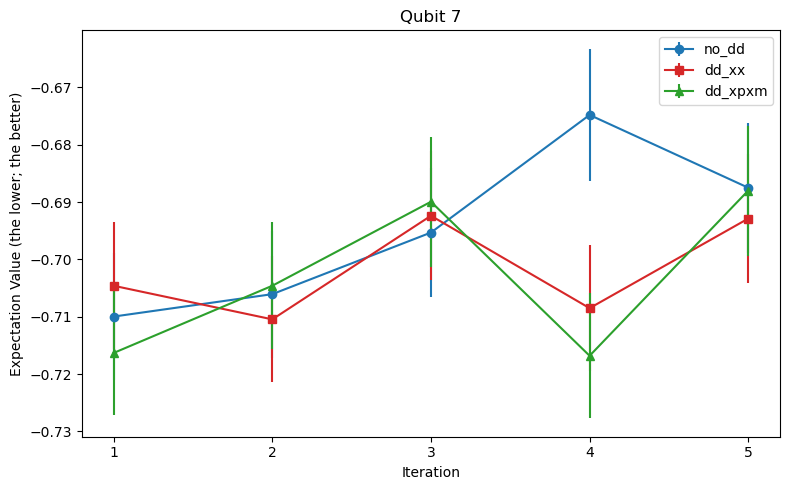

In [78]:
import numpy as np
import matplotlib.pyplot as plt

qubit = 7

# --- single qubit example (qubit 10) ---
iterations = np.arange(1, 5 + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_title(f"Qubit {qubit}")
ax.set_xticks(iterations)
ax.set_xlabel("Iteration")
ax.set_ylabel("Expectation Value (the lower; the better)")

ax.errorbar(iterations, qubit_7["no_dd_evs"], yerr=qubit_7["no_dd_std"], fmt='o-', color='#1f77b4', label='no_dd')
ax.errorbar(iterations, qubit_7["dd_xx_evs"], yerr=qubit_7["dd_xx_std"], fmt='s-', color='#d62728', label='dd_xx')
ax.errorbar(iterations, qubit_7["dd_xpxm_evs"], yerr=qubit_7["dd_xpxm_std"], fmt='^-', color='#2ca02c', label='dd_xpxm')
ax.legend()
plt.tight_layout()
plt.show()


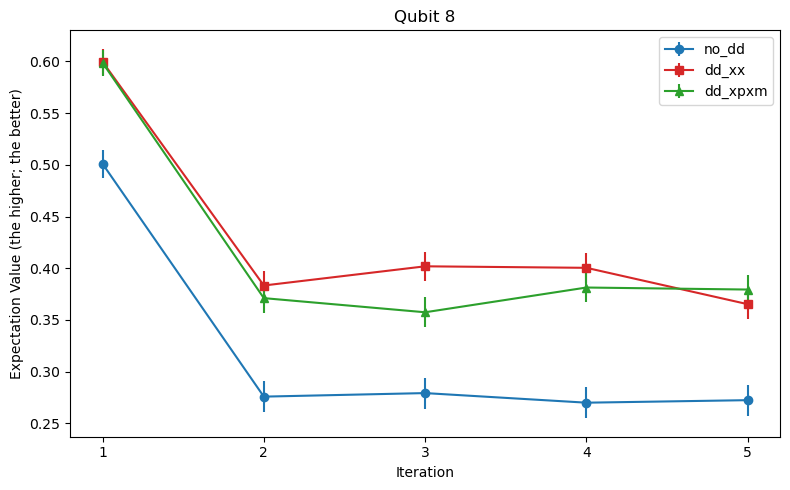

In [79]:
import numpy as np
import matplotlib.pyplot as plt

qubit = 8

# --- single qubit example (qubit 10) ---
iterations = np.arange(1, 5 + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_title(f"Qubit {qubit}")
ax.set_xticks(iterations)
ax.set_xlabel("Iteration")
ax.set_ylabel("Expectation Value (the higher; the better)")

ax.errorbar(iterations, qubit_8["no_dd_evs"], yerr=qubit_8["no_dd_std"], fmt='o-', color='#1f77b4', label='no_dd')
ax.errorbar(iterations, qubit_8["dd_xx_evs"], yerr=qubit_8["dd_xx_std"], fmt='s-', color='#d62728', label='dd_xx')
ax.errorbar(iterations, qubit_8["dd_xpxm_evs"], yerr=qubit_8["dd_xpxm_std"], fmt='^-', color='#2ca02c', label='dd_xpxm')
ax.legend()
plt.tight_layout()
plt.show()


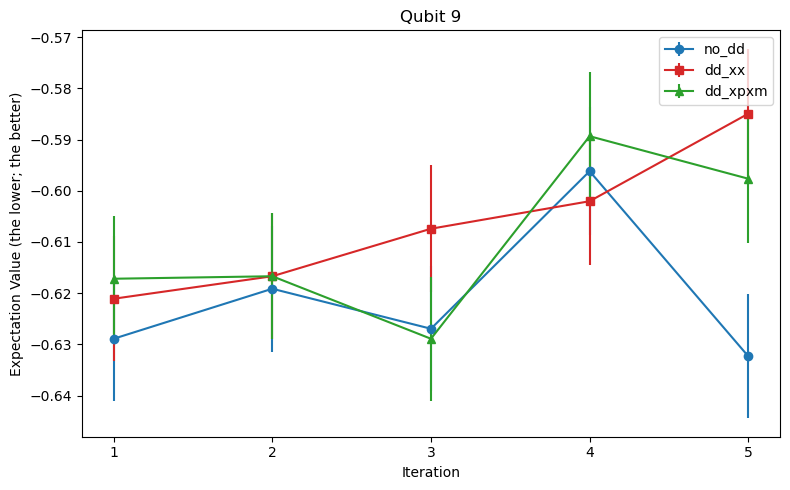

In [80]:
import numpy as np
import matplotlib.pyplot as plt

qubit = 9

# --- single qubit example (qubit 10) ---
iterations = np.arange(1, 5 + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_title(f"Qubit {qubit}")
ax.set_xticks(iterations)
ax.set_xlabel("Iteration")
ax.set_ylabel("Expectation Value (the lower; the better)")

ax.errorbar(iterations, qubit_9["no_dd_evs"], yerr=qubit_9["no_dd_std"], fmt='o-', color='#1f77b4', label='no_dd')
ax.errorbar(iterations, qubit_9["dd_xx_evs"], yerr=qubit_9["dd_xx_std"], fmt='s-', color='#d62728', label='dd_xx')
ax.errorbar(iterations, qubit_9["dd_xpxm_evs"], yerr=qubit_9["dd_xpxm_std"], fmt='^-', color='#2ca02c', label='dd_xpxm')
ax.legend()
plt.tight_layout()
plt.show()


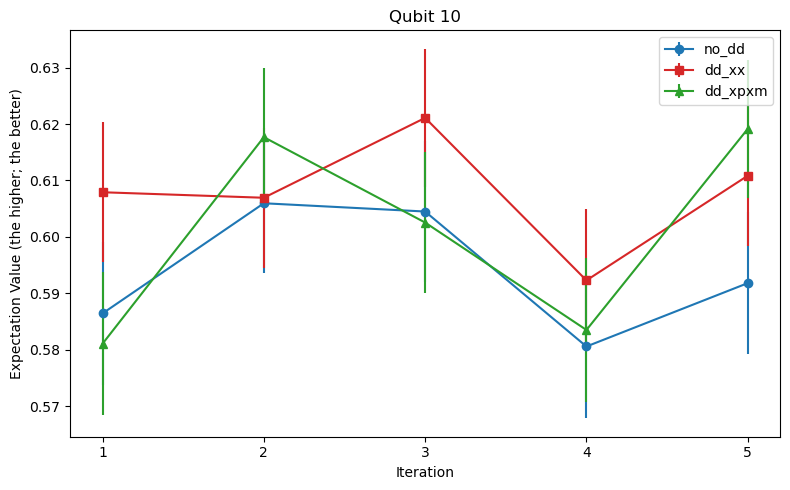

In [81]:
import numpy as np
import matplotlib.pyplot as plt

qubit = 10

# --- single qubit example (qubit 10) ---
iterations = np.arange(1, 5 + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_title(f"Qubit {qubit}")
ax.set_xticks(iterations)
ax.set_xlabel("Iteration")
ax.set_ylabel("Expectation Value (the higher; the better)")

ax.errorbar(iterations, qubit_10["no_dd_evs"], yerr=qubit_10["no_dd_std"], fmt='o-', color='#1f77b4', label='no_dd')
ax.errorbar(iterations, qubit_10["dd_xx_evs"], yerr=qubit_10["dd_xx_std"], fmt='s-', color='#d62728', label='dd_xx')
ax.errorbar(iterations, qubit_10["dd_xpxm_evs"], yerr=qubit_10["dd_xpxm_std"], fmt='^-', color='#2ca02c', label='dd_xpxm')
ax.legend()
plt.tight_layout()
plt.show()
